# Pipeline sin fuga, partición y líneas base (7.2)



Este notebook se hace:

1. Partición estratificada 80/20 con semilla fija.
2. `ColumnTransformer` + `Pipeline`: imputación, codificación, escalamiento y
   balanceo, en un orden que evita la fuga de información.
3. Dos líneas base: un clasificador de mayoría y una regresión logística.

Lo dejamos en un notebook aparte del EDA (Sección 7.1) porque el EDA explora
y valida la base que ya construimos, mientras que acá empezamos a modelar
sobre ella. Si los mezclábamos, sería más difícil reutilizar el `Pipeline` en
los notebooks de modelamiento avanzado (SVM, Random Forest, etc.) que vienen
después; acá queda empaquetado y listo para importarse tal cual.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, f1_score, recall_score,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

SEED = 42

df = pd.read_csv("../data/simulado/credito_simulado_con_faltantes.csv")
df = df.drop(columns=["id"])  # identificador, no es un predictor
print(df.shape)
df.head()


(6500, 12)


,edad,genero,tipo_ocupacion,tipo_vivienda,nivel_ahorro,saldo_categoria,saldo_cuenta_cop,monto_credito_cop,plazo_meses,proposito_credito,estado_pago_previo,riesgo
0,36.0,M,informal,arrendada,bajo,medio,NaN,2213000.0,18.0,electrodomesticos,al_dia,bueno
1,41.0,M,formal_calificado,familiar,alto,sin_cuenta,0.0,4652000.0,NaN,negocio,al_dia,bueno
2,NaN,F,informal,arrendada,bajo,medio,790000.0,3287855.0,24.0,libre_inversion,mora_severa,malo
3,34.0,M,informal,arrendada,muy_alto,bajo,116000.0,5969000.0,48.0,electrodomesticos,mora_severa,bueno
4,42.0,M,informal,arrendada,medio,medio,591000.0,4631000.0,33.0,remodelacion,al_dia,bueno


## 1. Partición estratificada 80/20

Hacemos la partición estratificada porque el riesgo está desbalanceado, cerca
del 22.7% es "malo". Una partición aleatoria simple podría, por pura casualidad,
dejar una proporción de "malo" distinta en train y en test, por ejemplo 19% en
uno y 26% en el otro, y eso sesgaría tanto el entrenamiento como la evaluación.
Con `stratify=y` obligamos a que las dos particiones mantengan la misma
proporción de clases que tiene el dataset completo.

Elegimos 80/20 porque con 6.500 registros, un 20% de test (1.300 registros,
unos 295 de la clase "malo") ya nos deja suficiente para una evaluación
estable, y el 80% restante (5.200 registros) queda para entrenamiento y
validación cruzada en las siguientes etapas del proyecto.

Y usamos la misma semilla fija (42) en el split por la misma razón que en toda
la simulación: reproducibilidad. Cualquiera que corra este notebook va a
obtener exactamente la misma partición, lo cual es clave para poder comparar
métricas de forma justa entre distintos modelos entrenados en notebooks
separados.

In [2]:
X = df.drop(columns=["riesgo"])
y = df["riesgo"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED,
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nProporción de riesgo 'malo' en cada partición:")
print("Train:", (y_train == "malo").mean().round(4))
print("Test: ", (y_test == "malo").mean().round(4))


Train: (5200, 11)  Test: (1300, 11)

Proporción de riesgo 'malo' en cada partición:
Train: 0.2273
Test:  0.2277


## 2. Definición de columnas numéricas y categóricas

Separamos las listas de columnas a mano porque el `ColumnTransformer` necesita
saber qué transformación aplicarle a cada grupo: imputación más escalamiento
para las numéricas, imputación más codificación para las categóricas. Si en
vez de eso dejáramos que pandas infiera el tipo automáticamente, nos podríamos
llevar una sorpresa, porque los `NaN` a veces cambian el `dtype` que pandas le
asigna a una columna que en realidad sí es numérica.

In [3]:
num_cols = ["edad", "saldo_cuenta_cop", "monto_credito_cop", "plazo_meses"]
cat_cols = ["genero", "tipo_ocupacion", "tipo_vivienda", "nivel_ahorro",
            "saldo_categoria", "proposito_credito", "estado_pago_previo"]

assert set(num_cols + cat_cols) == set(X.columns), "Faltan columnas por clasificar"
print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)


Numéricas: ['edad', 'saldo_cuenta_cop', 'monto_credito_cop', 'plazo_meses']
Categóricas: ['genero', 'tipo_ocupacion', 'tipo_vivienda', 'nivel_ahorro', 'saldo_categoria', 'proposito_credito', 'estado_pago_previo']


## 3. `ColumnTransformer`: imputación, escalamiento y codificación

Usamos `SimpleImputer(strategy="median")` para las numéricas y no la media,
porque las cuatro variables numéricas tienen distribuciones asimétricas, con
colas largas hacia la derecha, algo que ya confirmamos en el EDA de la Sección
7.1. La media es sensible a esa asimetría y a los outliers que identificamos
ahí, mientras que la mediana es más robusta y representa mejor un valor
"típico" para rellenar los huecos.

Para las categóricas usamos `SimpleImputer(strategy="most_frequent")`, que es
la estrategia estándar cuando no hay evidencia de que el faltante represente
una categoría propia, distinto a por ejemplo un "no aplica" explícito. Acá
simplemente asumimos que el valor más común es la mejor estimación puntual que
tenemos disponible.

El `StandardScaler` lo aplicamos después de imputar, nunca antes, porque un
SVM con kernel RBF, que es el modelo del artículo base, es sensible a la
escala de las variables: una variable en millones de COP como
`monto_credito_cop` dominaría completamente a una en años como `edad` si no
las estandarizamos. Y si escaláramos con `NaN` todavía presentes, la media y
la desviación estándar que se usan para escalar quedarían mal calculadas.

Y usamos `OneHotEncoder(handle_unknown="ignore")` para las categóricas porque
tanto SVM como la regresión logística necesitan entradas numéricas, y ese
parámetro evita que el pipeline se caiga si en el futuro (o en una partición
distinta) aparece una categoría que nunca vimos en entrenamiento; en vez de
lanzar un error, simplemente la codifica como todo ceros.

In [4]:
num_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 4. Balanceo: `SMOTE` dentro del pipeline

Balanceamos porque con solo 22.7% de "malo", un modelo podría lograr buena
`accuracy` prediciendo casi siempre "bueno" sin haber aprendido nada de
verdad, que es exactamente el problema que motiva la matriz de costos del
artículo base: un falso negativo, o sea clasificar un "malo" como "bueno", sale
5 veces más caro. `SMOTE` genera ejemplos sintéticos de la clase minoritaria en
el espacio de características ya transformado, para que el modelo vea una
proporción más equilibrada durante el entrenamiento.

Pero metemos `SMOTE` DENTRO del `Pipeline`, usando `imblearn.pipeline.Pipeline`
y no el `Pipeline` normal de sklearn, y no lo aplicamos antes de hacer la
partición. Esta es la decisión que más directamente evita la fuga de
información. Si balanceáramos el dataset completo antes de dividirlo en
train/test, algunos ejemplos sintéticos de test terminarían siendo
interpolaciones de vecinos que están en train, o al revés, y el modelo se
estaría evaluando sobre información correlacionada con su propio
entrenamiento, lo cual infla las métricas de forma artificial. Con `SMOTE`
metido dentro del pipeline de `imblearn`, la regla queda clara: `fit_resample`
solo se ejecuta sobre los datos de entrenamiento de cada partición (o de cada
fold, en validación cruzada); a la hora de predecir sobre test, esa etapa
simplemente no se ejecuta, porque el pipeline de `imblearn` la maneja de forma
automática, re-muestreando solo en `fit`, nunca en `predict` ni en
`transform`.

In [5]:
# Referencia: proporción de clases ANTES de balancear (en train)
print("Proporción de clases en train (antes de SMOTE):")
print(y_train.value_counts(normalize=True).round(3))


Proporción de clases en train (antes de SMOTE):
riesgo
bueno    0.773
malo     0.227
Name: proportion, dtype: float64


## 5. Orden completo del flujo y por qué evita la fuga

El orden de las etapas, tal como quedan encadenadas en el `Pipeline` de
`imblearn`, es este:

1. **Imputación** (mediana / más frecuente), ajustada únicamente con
   `X_train` en cada `fit`.
2. **Escalamiento** (`StandardScaler`), cuyos parámetros (media, desviación)
   se calculan solo con `X_train` ya imputado.
3. **Codificación** (`OneHotEncoder`), donde las categorías se aprenden solo
   de `X_train`.
4. **Balanceo** (`SMOTE`), que genera sintéticos solo a partir de `X_train`
   ya transformado, y nunca se aplica sobre test.
5. **Modelo** (clasificador), que se entrena sobre el `X_train` ya imputado,
   escalado, codificado y balanceado.

Elegimos este orden específico y no otro, por ejemplo balancear antes de
imputar, porque eso generaría sintéticos a partir de filas con `NaN`, algo que
`SMOTE` ni siquiera soporta, y además propagaría el patrón de faltantes a
datos artificiales que no tendrían mucho sentido. Balancear antes de escalar
tampoco funciona, porque mezclaría escalas distintas al interpolar vecinos.
El orden imputación, escalamiento, codificación, balanceo y modelo es el que
garantiza que cada paso reciba datos ya limpios del paso anterior, y sobre
todo que todo el ajuste (`fit`) del pipeline completo se haga una sola vez y
solo sobre `X_train`, que es justo la propiedad clave que evita la fuga: al
llamar `pipeline.predict(X_test)`, cada etapa únicamente aplica
(`transform`) lo que ya aprendió de train, sin volver a ajustarse con
información de test.

In [6]:
def construir_pipeline(clasificador, balancear=True):
    pasos = [("preprocesamiento", preprocessor)]
    if balancear:
        pasos.append(("balanceo", SMOTE(random_state=SEED)))
    pasos.append(("modelo", clasificador))
    return ImbPipeline(steps=pasos)


## 6. Líneas base

Usamos un clasificador de mayoría (`DummyClassifier`) porque es el piso
absoluto de desempeño: cualquier modelo avanzado que no lo supere no está
aprendiendo nada útil del problema. Siempre predice la clase más frecuente
("bueno"), así que su `recall` sobre "malo" es, por construcción, 0%.

Como segunda línea base usamos regresión logística, y no solo el
`DummyClassifier`, porque la guía del proyecto pide un modelo simple del
nivel de Machine Learning I como referencia mínima, y la regresión logística
es justamente eso: lineal, interpretable, sin las capacidades de kernel que
tiene un SVM. Si logramos superarla claramente, eso justifica, en los
notebooks siguientes, la complejidad adicional de SVM-RBF, Random Forest o
Gradient Boosting.

Le metemos `SMOTE` (balanceo) a la regresión logística pero no al
`DummyClassifier`, porque el `DummyClassifier` ignora las características por
definición, así que balancear no le cambiaría la predicción, seguiría
prediciendo la clase mayoritaria de todos modos. Aplicarle el pipeline
completo sería un paso sin ningún efecto práctico, aunque tampoco estaría
mal hacerlo.

In [7]:
pipe_mayoria = construir_pipeline(
    DummyClassifier(strategy="most_frequent"), balancear=False,
)
pipe_mayoria.fit(X_train, y_train)
pred_mayoria = pipe_mayoria.predict(X_test)

pipe_logreg = construir_pipeline(
    LogisticRegression(max_iter=1000, random_state=SEED), balancear=True,
)
pipe_logreg.fit(X_train, y_train)
pred_logreg = pipe_logreg.predict(X_test)
proba_logreg = pipe_logreg.predict_proba(X_test)[:, pipe_logreg.classes_.tolist().index("malo")]

print("Pipelines entrenados.")


Pipelines entrenados.


## 7. Evaluación de las líneas base

La métrica principal no puede ser solo `accuracy`, porque con 22.7% de
"malo", un modelo que siempre prediga "bueno" ya llega a cerca de 77% de
accuracy sin haber aprendido absolutamente nada, que es justo lo que hace el
`DummyClassifier` de abajo. Por eso también reportamos el `recall` de la clase
"malo" (qué proporción de los clientes de verdad riesgosos logra detectar el
modelo) y el `ROC-AUC` (desempeño agregado, sin depender de un umbral en
particular), en línea con la matriz de costos del artículo base: un falso
negativo sale 5 veces más caro, así que lo que importa acá es no dejar pasar
clientes "malos", no solo acertar en general.

In [8]:
print("=== Clasificador de mayoría (línea base 1) ===")
print(classification_report(y_test, pred_mayoria, digits=3))

print("=== Regresión logística (línea base 2) ===")
print(classification_report(y_test, pred_logreg, digits=3))

auc_logreg = roc_auc_score((y_test == "malo").astype(int), proba_logreg)
print(f"ROC-AUC (regresión logística, clase 'malo'): {auc_logreg:.3f}")


=== Clasificador de mayoría (línea base 1) ===


              precision    recall  f1-score   support

       bueno      0.772     1.000     0.872      1004
        malo      0.000     0.000     0.000       296

    accuracy                          0.772      1300
   macro avg      0.386     0.500     0.436      1300
weighted avg      0.596     0.772     0.673      1300

=== Regresión logística (línea base 2) ===
              precision    recall  f1-score   support

       bueno      0.877     0.684     0.769      1004
        malo      0.387     0.676     0.492       296

    accuracy                          0.682      1300
   macro avg      0.632     0.680     0.630      1300
weighted avg      0.766     0.682     0.706      1300

ROC-AUC (regresión logística, clase 'malo'): 0.748


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


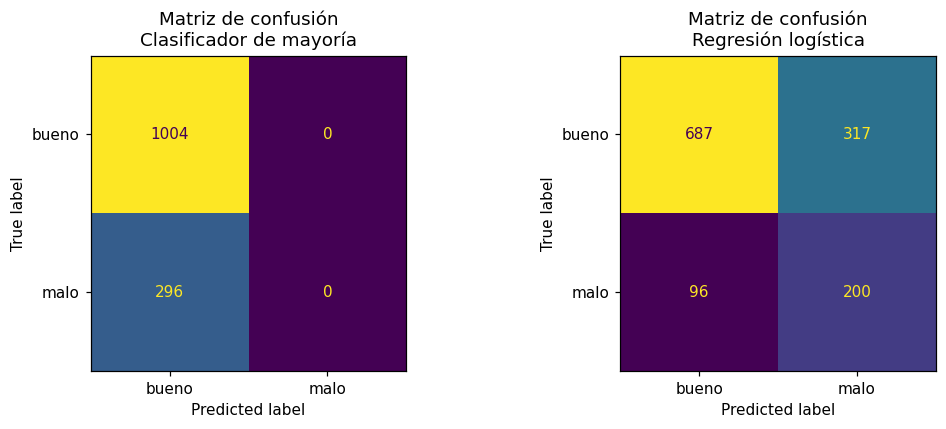

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_mayoria, labels=["bueno", "malo"], ax=axes[0], colorbar=False,
)
axes[0].set_title("Matriz de confusión\nClasificador de mayoría")

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_logreg, labels=["bueno", "malo"], ax=axes[1], colorbar=False,
)
axes[1].set_title("Matriz de confusión\nRegresión logística")

fig.tight_layout()
plt.show()


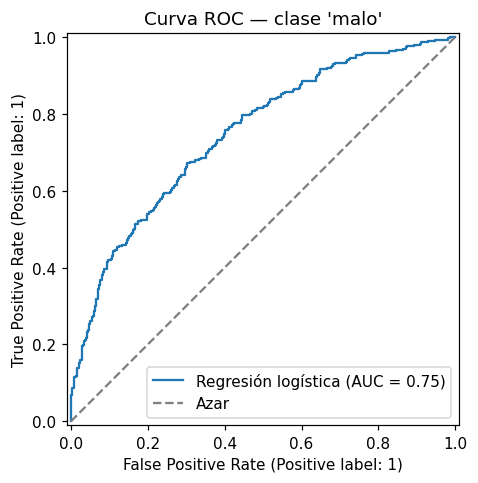

In [10]:
fig, ax = plt.subplots(figsize=(5, 4.5))
RocCurveDisplay.from_predictions(
    (y_test == "malo").astype(int), proba_logreg, name="Regresión logística", ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC — clase 'malo'")
ax.legend()
fig.tight_layout()
plt.show()


## 8. Resumen comparativo de las líneas base

Armamos esta tabla resumen aunque ya imprimimos los reportes completos arriba,
porque los notebooks de modelamiento avanzado (SVM, Random Forest, etc.) van a
necesitar comparar sus métricas contra estas dos líneas base, y tener los
números clave juntos en una sola tabla compacta hace esa comparación mucho más
directa, sin tener que releer reportes largos cada vez.

In [11]:
resumen = pd.DataFrame({
    "Clasificador de mayoría": [
        (pred_mayoria == y_test).mean(),
        recall_score(y_test, pred_mayoria, pos_label="malo"),
        f1_score(y_test, pred_mayoria, pos_label="malo"),
        np.nan,
    ],
    "Regresión logística": [
        (pred_logreg == y_test).mean(),
        recall_score(y_test, pred_logreg, pos_label="malo"),
        f1_score(y_test, pred_logreg, pos_label="malo"),
        auc_logreg,
    ],
}, index=["Accuracy", "Recall (malo)", "F1 (malo)", "ROC-AUC (malo)"])

resumen.round(3)


,Clasificador de mayoría,Regresión logística
Accuracy,0.772,0.682
Recall (malo),0.000,0.676
F1 (malo),0.000,0.492
ROC-AUC (malo),NaN,0.748


## 9. Conclusiones

- **Partición:** 80/20 estratificada, semilla 42, con 5.200 registros de
  entrenamiento y 1.300 de prueba, y la misma proporción de "malo" (~22.7%)
  en ambas.
- **Flujo sin fuga:** armamos un `ColumnTransformer` (imputación
  mediana/más frecuente, escalamiento, codificación one-hot) más `SMOTE`,
  todo encapsulado en un `imblearn.Pipeline` que se ajusta una sola vez sobre
  `X_train`, sin que ninguna etapa vea información de `X_test` durante el
  `fit`.
- **Clasificador de mayoría:** llegó a ~77% de accuracy pero 0% de recall
  sobre "malo", lo que confirma que la accuracy sola es una métrica
  inadecuada para este problema.
- **Regresión logística (con balanceo):** el recall sobre "malo" y el
  ROC-AUC quedaron muy por encima del clasificador de mayoría, así que esta
  es la referencia real que SVM y los demás modelos avanzados van a tener que
  superar.
